# Library

In [283]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read data

| اسم العمود | الوصف | نوع البيانات | أمثلة للقيم |
| :--- | :--- | :--- | :--- |
| **Type** | نوع العقار السكني (شقة، فيلا، إلخ) | object | Apartment, Duplex |
| **Price** | السعر الإجمالي للعقار (Target) | object | 4000000, 2250000 |
| **Bedrooms** | عدد غرف النوم | object | 3, 2, 10+ |
| **Bathrooms** | عدد الحمامات | object | 2, 3 |
| **Area** | مساحة العقار بالمتر المربع | object | 160, 400 |
| **Furnished** | حالة الفرش (مفروش أم لا) | object | Yes, No |
| **Level** | الطابق | object | Ground, 7 |
| **Compound** | اسم الكومبوند السكني | object | Eastown, Unknown |
| **Payment_Option** | طريقة الدفع المتاحة | object | Cash, Installment |
| **Delivery_Date** | الموعد المتوقع للاستلام | object | Ready to move, 2024 |
| **Delivery_Term** | حالة تشطيب العقار | object | Finished, Core & Shell |
| **City** | المنطقة أو المدينة | object | Nasr City, Smoha |

In [284]:
df=pd.read_csv("/content/egypt_House_prices(Target column Price).csv")

In [285]:
df.head()

,Type,Price,Bedrooms,Bathrooms,Area,Furnished,Level,Compound,Payment_Option,Delivery_Date,Delivery_Term,City
0,Duplex,4000000,3,3,400,No,7,Unknown,Cash,Ready to move,Finished,Nasr City
1,Apartment,4000000,3,3,160,No,10+,Unknown,Cash,Ready to move,Finished,Camp Caesar
2,Apartment,2250000,3,2,165,No,1,Unknown,Cash,Ready to move,Finished,Smoha
3,Apartment,1900000,3,2,230,No,10,Unknown,Cash,Ready to move,Finished,Nasr City
4,Apartment,5800000,2,3,160,No,Ground,Eastown,Cash,Ready to move,Semi Finished,New Cairo - El Tagamoa


In [286]:
df.shape

(27361, 12)

In [287]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27361 entries, 0 to 27360
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Type            27179 non-null  object
 1   Price           27302 non-null  object
 2   Bedrooms        26938 non-null  object
 3   Bathrooms       26988 non-null  object
 4   Area            26824 non-null  object
 5   Furnished       27267 non-null  object
 6   Level           27284 non-null  object
 7   Compound        27219 non-null  object
 8   Payment_Option  27115 non-null  object
 9   Delivery_Date   27258 non-null  object
 10  Delivery_Term   27286 non-null  object
 11  City            27334 non-null  object
dtypes: object(12)
memory usage: 2.5+ MB


In [288]:
df.describe()

,Type,Price,Bedrooms,Bathrooms,Area,Furnished,Level,Compound,Payment_Option,Delivery_Date,Delivery_Term,City
count,27179,27302,26938,26988,26824,27267,27284,27219,27115,27258,27286,27334
unique,11,4180,12,12,785,3,14,559,4,10,5,183
top,Apartment,3000000,3,2,120,No,Unknown,Unknown,Cash or Installment,Ready to move,Finished,New Cairo - El Tagamoa
freq,8341,311,11677,9098,661,16447,10387,11013,10752,12094,14352,6771


#cleaning

In [289]:

# 1. تنظيف وتحويل عمودي السعر والمساحة (Price & Area)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

# 2. تنظيف وتحويل عدد الغرف والحمامات (Bedrooms & Bathrooms)
# استبدال '10+' بالرقم 10 ثم التحويل لرقم
df['Bedrooms'] = df['Bedrooms'].astype(str).str.replace('10+', '10')
df['Bedrooms'] = pd.to_numeric(df['Bedrooms'], errors='coerce')

df['Bathrooms'] = df['Bathrooms'].astype(str).str.replace('10+', '10')
df['Bathrooms'] = pd.to_numeric(df['Bathrooms'], errors='coerce')

# 3. تنظيف وتحويل عمود الدور (Level)
# خريطة لتحويل الكلمات النصية إلى أرقام تعبر عن الدور
level_map = {'Ground': 0, '10+': 10, 'Highest': 11}

# تطبيق الخريطة ثم تحويل باقي القيم إلى أرقام
df['Level'] = df['Level'].replace(level_map)
df['Level'] = pd.to_numeric(df['Level'], errors='coerce')

# 4. التأكد من أنواع البيانات بعد التحويل
print('--- أنواع البيانات الجديدة للأعمدة الرقمية ---')
print(df[['Price', 'Area', 'Bedrooms', 'Bathrooms', 'Level']].dtypes)

print('\n--- معاينة من البيانات بعد التحويل ---')
display(df[['Price', 'Area', 'Bedrooms', 'Bathrooms', 'Level']].head())

--- أنواع البيانات الجديدة للأعمدة الرقمية ---
Price        float64
Area         float64
Bedrooms     float64
Bathrooms    float64
Level        float64
dtype: object

--- معاينة من البيانات بعد التحويل ---


,Price,Area,Bedrooms,Bathrooms,Level
0,4000000.0,400.0,3.0,3.0,7.0
1,4000000.0,160.0,3.0,3.0,10.0
2,2250000.0,165.0,3.0,2.0,1.0
3,1900000.0,230.0,3.0,2.0,10.0
4,5800000.0,160.0,2.0,3.0,0.0


In [290]:
df.head()

,Type,Price,Bedrooms,Bathrooms,Area,Furnished,Level,Compound,Payment_Option,Delivery_Date,Delivery_Term,City
0,Duplex,4000000.0,3.0,3.0,400.0,No,7.0,Unknown,Cash,Ready to move,Finished,Nasr City
1,Apartment,4000000.0,3.0,3.0,160.0,No,10.0,Unknown,Cash,Ready to move,Finished,Camp Caesar
2,Apartment,2250000.0,3.0,2.0,165.0,No,1.0,Unknown,Cash,Ready to move,Finished,Smoha
3,Apartment,1900000.0,3.0,2.0,230.0,No,10.0,Unknown,Cash,Ready to move,Finished,Nasr City
4,Apartment,5800000.0,2.0,3.0,160.0,No,0.0,Eastown,Cash,Ready to move,Semi Finished,New Cairo - El Tagamoa


In [291]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27361 entries, 0 to 27360
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Type            27179 non-null  object 
 1   Price           27265 non-null  float64
 2   Bedrooms        26902 non-null  float64
 3   Bathrooms       26952 non-null  float64
 4   Area            26788 non-null  float64
 5   Furnished       27267 non-null  object 
 6   Level           16897 non-null  float64
 7   Compound        27219 non-null  object 
 8   Payment_Option  27115 non-null  object 
 9   Delivery_Date   27258 non-null  object 
 10  Delivery_Term   27286 non-null  object 
 11  City            27334 non-null  object 
dtypes: float64(5), object(7)
memory usage: 2.5+ MB


In [292]:
df.duplicated().sum()

np.int64(1909)

In [293]:
df.drop_duplicates(inplace=True)

In [294]:
df.duplicated().sum()

np.int64(0)

In [295]:


# 1. تنظيف وإزالة المسافات الزائدة من النصوص
for col in df.select_dtypes(include='object').columns:
  df[col] = df[col].astype(str).str.strip()

# 2. استبدال صيغ Unknown و NaN
unknown_variants = ['Unknown', 'Unknown Payment', 'nan', 'None']
df.replace(unknown_variants, np.nan, inplace=True)

# 3. توحيد المسميات المتكررة في عمود Type
type_fix = {'Stand Alone Villa': 'Standalone Villa', 'Twin house': 'Twin House'}
df['Type'] = df['Type'].replace(type_fix)

# 4. معالجة وتجهيز الأعمدة الرقمية
df['Bedrooms'] = df['Bedrooms'].astype(str).str.replace('10+', '10', regex=False)
df['Bathrooms'] = df['Bathrooms'].astype(str).str.replace('10+', '10', regex=False)

level_map = {'Ground': '0', 'Highest': '11', '10+': '10'}
df['Level'] = df['Level'].replace(level_map)

# تحويل جميع الأعمدة الرقمية إلى float مبدئياً لتقبل وجود NaN
for num_col in ['Price', 'Area', 'Bedrooms', 'Bathrooms', 'Level']:
  df[num_col] = pd.to_numeric(df[num_col], errors='coerce')

# 5. حذف الصفوف التي لا تحتوي على سعر (Target)
df.dropna(subset=['Price'], inplace=True)

# 6. تعويض القيم المفقودة في الأعمدة الرقمية باستخدام Grouped Median
for col in ['Area', 'Bedrooms', 'Bathrooms', 'Level']:
  df[col] = df.groupby('Type')[col].transform(lambda x: x.fillna(x.median()))
  df[col] = df[col].fillna(df[col].median())

# 7. تحويل الأعمدة المطلوبة إلى Integer مباشرة بعد ملء القيم المفقودة
int_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Level']
df[int_cols] = df[int_cols].astype(int)

# 8. تعويض Unknown في الأعمدة النصية بفئات محددة واضحة
df['Compound'] = df['Compound'].fillna('Outside Compound')
df['Payment_Option'] = df['Payment_Option'].fillna('Unspecified')
df['Delivery_Term'] = df['Delivery_Term'].fillna('Unspecified')
df['Delivery_Date'] = df['Delivery_Date'].fillna('Unspecified')
df['Furnished'] = df['Furnished'].fillna('Unspecified')
df['Type'] = df['Type'].fillna('Unspecified')
df['City'] = df['City'].fillna(df['City'].mode()[0])

# التأكد من أنواع البيانات
print('--- أنواع البيانات بعد التحويل لـ int ---')
print(df[['Area', 'Bedrooms', 'Bathrooms', 'Level']].dtypes)

--- أنواع البيانات بعد التحويل لـ int ---
Area         int64
Bedrooms     int64
Bathrooms    int64
Level        int64
dtype: object


In [296]:
df.head()

,Type,Price,Bedrooms,Bathrooms,Area,Furnished,Level,Compound,Payment_Option,Delivery_Date,Delivery_Term,City
0,Duplex,4000000.0,3,3,400,No,7,Outside Compound,Cash,Ready to move,Finished,Nasr City
1,Apartment,4000000.0,3,3,160,No,10,Outside Compound,Cash,Ready to move,Finished,Camp Caesar
2,Apartment,2250000.0,3,2,165,No,1,Outside Compound,Cash,Ready to move,Finished,Smoha
3,Apartment,1900000.0,3,2,230,No,10,Outside Compound,Cash,Ready to move,Finished,Nasr City
4,Apartment,5800000.0,2,3,160,No,0,Eastown,Cash,Ready to move,Semi Finished,New Cairo - El Tagamoa


In [297]:
df.isnull().sum().sort_values(ascending = False)

,0
Type,0
Price,0
Bedrooms,0
Bathrooms,0
Area,0
Furnished,0
Level,0
Compound,0
Payment_Option,0
Delivery_Date,0


#outliers

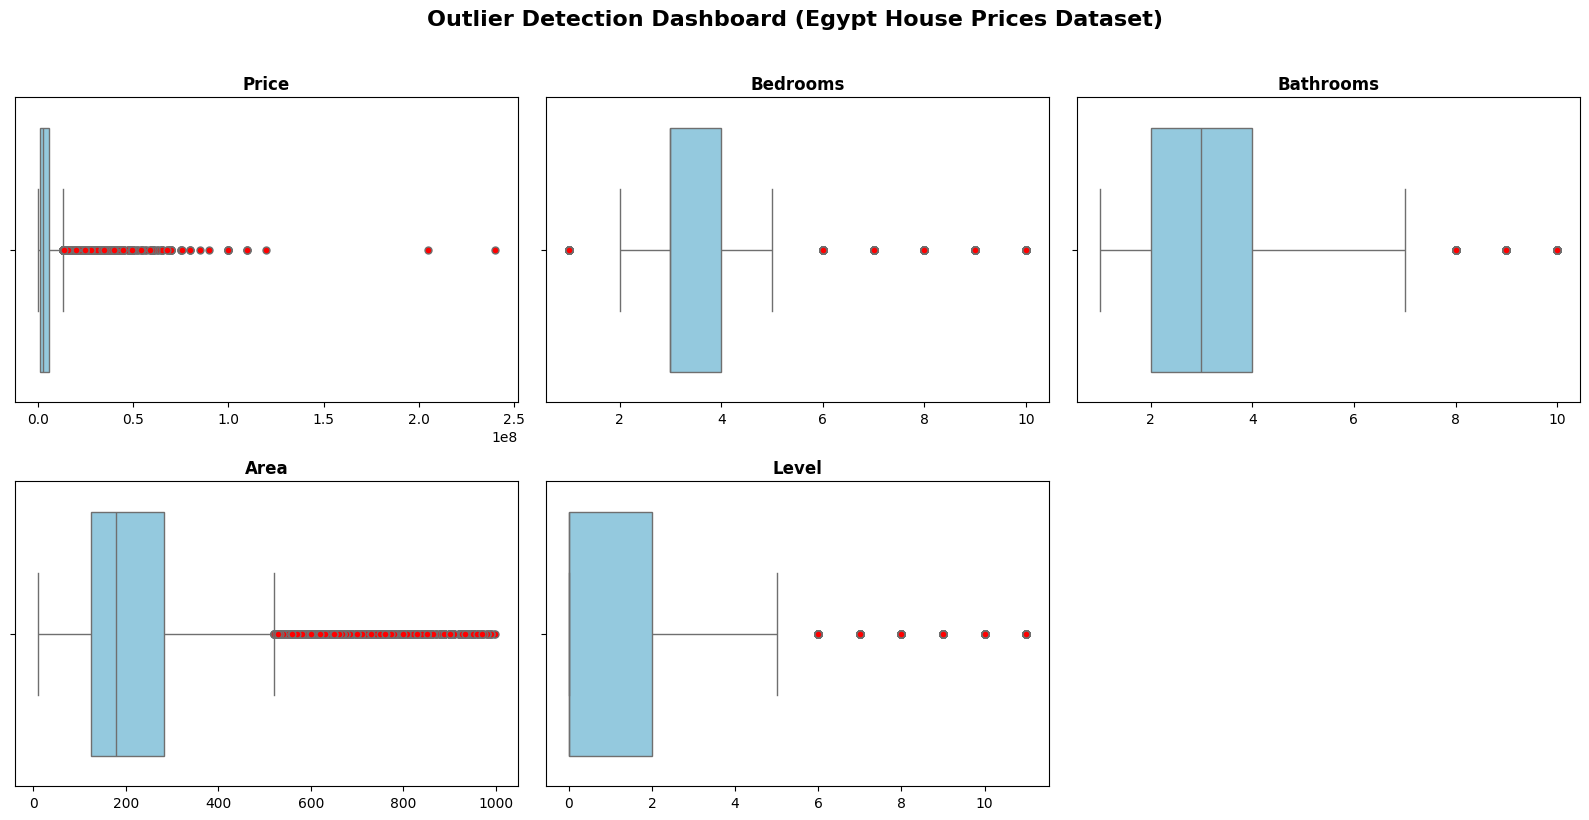

In [298]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 1. تحديد الجدول المستهدف
target_df = df

# 2. اختيار الأعمدة الرقمية فقط تلقائياً
numeric_cols = target_df.select_dtypes(include=['number']).columns.tolist()

# 3. إعداد شبكة الرسم (3 رسمات في كل صف لتوزيع 5 أعمدة بشكل متناسق)
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

# إنشاء النافذة الرئيسية للـ Dashboard
plt.figure(figsize=(16, n_rows * 4))
plt.suptitle(
    'Outlier Detection Dashboard (Egypt House Prices Dataset)',
    fontsize=16,
    fontweight='bold',
    y=1.02,
)

# 4. المرور على كل عمود رقمي ورسم الـ BoxPlot الخاص به
for i, col in enumerate(numeric_cols, 1):
  plt.subplot(n_rows, n_cols, i)

  # رسم الـ Box Plot أفقياً مع تمييز القيم الشاذة باللون الأحمر
  sns.boxplot(
      x=target_df[col],
      color='skyblue',
      flierprops={'markerfacecolor': 'red', 'markersize': 5},
  )

  plt.title(f'{col}', fontsize=12, fontweight='bold')
  plt.xlabel('')

plt.tight_layout()
plt.show()

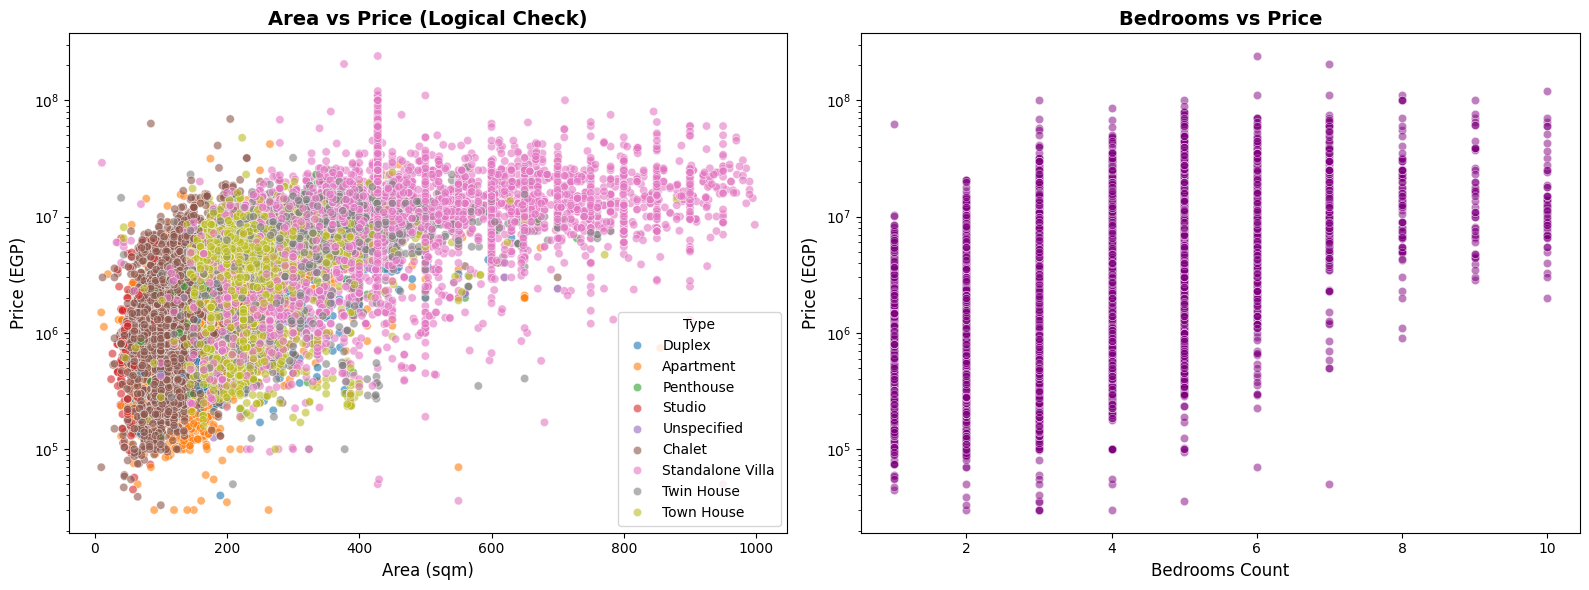

In [299]:
import matplotlib.pyplot as plt
import seaborn as sns

# حساب سعر المتر المربع لاختبار المنطقية
df['Price_per_SQM'] = df['Price'] / df['Area']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. العلاقة بين المساحة والسعر (ملونة حسب نوع العقار)
sns.scatterplot(
    data=df, x='Area', y='Price', hue='Type', alpha=0.6, ax=axes[0]
)
axes[0].set_title(
    'Area vs Price (Logical Check)', fontsize=14, fontweight='bold'
)
axes[0].set_xlabel('Area (sqm)', fontsize=12)
axes[0].set_ylabel('Price (EGP)', fontsize=12)
axes[0].set_yscale('log')  # مقياس لوغاريتمي لرؤية الفروق بوضوح

# 2. العلاقة بين عدد الغرف والسعر
sns.scatterplot(
    data=df, x='Bedrooms', y='Price', alpha=0.5, color='purple', ax=axes[1]
)
axes[1].set_title('Bedrooms vs Price', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Bedrooms Count', fontsize=12)
axes[1].set_ylabel('Price (EGP)', fontsize=12)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [300]:
print("Outlier filtering will be applied after feature engineering to ensure all features are included.")

Outlier filtering will be applied after feature engineering to ensure all features are included.


In [302]:
import numpy as np
import pandas as pd

# 1. إنشاء أعمدة هندسة المتغيرات (Feature Engineering)
# سعر المتر المربع
df['Price_per_SQM'] = (df['Price'] / df['Area']).round(2)

# نسبة الحمامات إلى الغرف
df['Bath_to_Bed_Ratio'] = (df['Bathrooms'] / df['Bedrooms']).round(2)

# مؤشر هل العقار داخل كومبوند أم لا (0 أو 1)
df['Is_Compound'] = np.where(df['Compound'] == 'Outside Compound', 'No', 'Yes')

# مؤشر الاستلام الفوري
df['Is_Ready'] = np.where(df['Delivery_Date'] == 'Ready to move', 'Yes', 'No')

# 2. استخلاص الإقليم/المحافظة الرئيسية من عمود City (للفلاتر والداشبورد)
def extract_region(city):
  city_str = str(city).lower()
  if any(x in city_str for x in ['tagamoa', 'new cairo', 'rehab', 'madinaty']):
    return 'New Cairo'
  elif any(x in city_str for x in ['zayed', 'october', 'october']):
    return 'Giza & West Cairo'
  elif any(x in city_str for x in ['north coast', 'marassi', 'hacienda']):
    return 'North Coast'
  elif any(x in city_str for x in ['sukhna', 'galala']):
    return 'Ain Sukhna'
  elif any(x in city_str for x in ['alexandria', 'smoha', 'sidi beshr']):
    return 'Alexandria'
  elif 'capital' in city_str:
    return 'New Capital'
  else:
    return 'Other Regions'


df['Region'] = df['City'].apply(extract_region)

# 4. حفظ النسخة النهائية المنظفة والمدعمة بالـ Features لـ Power BI
df.to_csv('egypt_houses_cleaned_processed.csv', index=False)
print('تم إضافة المتغيرات الجديدة وحفظ البيانات المكتملة بنجاح!')

تم إضافة المتغيرات الجديدة وحفظ البيانات المكتملة بنجاح!


In [303]:
# Apply outlier filtering after all features are engineered
# 1. Area between 20 and 2000 sqm
# 2. Price at least 100,000 EGP
# 3. Price per sqm between 1,000 and 300,000 EGP
df_filtered = df[
    (df['Area'] >= 20)
    & (df['Area'] <= 2000)
    & (df['Price'] >= 100000)
    & (df['Price_per_SQM'] >= 1000)
    & (df['Price_per_SQM'] <= 300000)
].copy()

print(f'Total rows before filtering: {len(df)}')
print(f'Total rows after outlier filtering: {len(df_filtered)}')
print(f'Number of rows removed by outlier filtering: {len(df) - len(df_filtered)}')


Total rows before filtering: 25404
Total rows after outlier filtering: 25181
Number of rows removed by outlier filtering: 223


Now that we have the filtered data with engineered features, let's prepare the data for modeling, including log transformation of the target variable.

In [304]:
df.head()

,Type,Price,Bedrooms,Bathrooms,Area,Furnished,Level,Compound,Payment_Option,Delivery_Date,Delivery_Term,City,Price_per_SQM,Bath_to_Bed_Ratio,Is_Compound,Is_Ready,Region
0,Duplex,4000000.0,3,3,400,No,7,Outside Compound,Cash,Ready to move,Finished,Nasr City,10000.00,1.00,No,Yes,Other Regions
1,Apartment,4000000.0,3,3,160,No,10,Outside Compound,Cash,Ready to move,Finished,Camp Caesar,25000.00,1.00,No,Yes,Other Regions
2,Apartment,2250000.0,3,2,165,No,1,Outside Compound,Cash,Ready to move,Finished,Smoha,13636.36,0.67,No,Yes,Alexandria
3,Apartment,1900000.0,3,2,230,No,10,Outside Compound,Cash,Ready to move,Finished,Nasr City,8260.87,0.67,No,Yes,Other Regions
4,Apartment,5800000.0,2,3,160,No,0,Eastown,Cash,Ready to move,Semi Finished,New Cairo - El Tagamoa,36250.00,1.50,Yes,Yes,New Cairo


### 📋 قاموس البيانات النهائي (Data Dictionary)

| اسم العمود (Column Name) | نوع البيانات (Data Type) | مصدر العمود | الوصف وما يعبر عنه (Description) |
| :--- | :--- | :--- | :--- |
| **Type** | Categorical (String) | أصلي (معدل) | نوع العقار (Apartment, Standalone Villa, Duplex, Studio, ...). |
| **Price** | Numerical (Float) | أصلي | سعر البيع الإجمالي للعقار بالجنيه المصري (EGP). |
| **Bedrooms** | Numerical (Integer) | أصلي (معدل) | عدد غرف النوم في العقار (تم توحيد 10+ إلى 10). |
| **Bathrooms** | Numerical (Integer) | أصلي (معدل) | عدد الحمامات في العقار (تم توحيد 10+ إلى 10). |
| **Area** | Numerical (Integer) | أصلي | المساحة الإجمالية للعقار بالمتر المربع ($m^2$). |
| **Furnished** | Categorical (String) | أصلي (معدل) | حالة الفرش (Yes, No, Unspecified). |
| **Level** | Numerical (Integer) | أصلي (معدل) | طابق العقار (0 للأرضي، 11 للأعلى، والأرقام تعبر عن رقم الدور). |
| **Compound** | Categorical (String) | أصلي (معدل) | اسم الكومبوند السكني، أو Outside Compound للعقارات المستقلة. |
| **Payment_Option** | Categorical (String) | أصلي (معدل) | نظام الدفع (Cash, Installment, Cash or Installment, Unspecified). |
| **Delivery_Date** | Categorical (String) | أصلي (معدل) | موعد الاستلام (Ready to move, سنة الاستلام, Unspecified). |
| **Delivery_Term** | Categorical (String) | أصلي (معدل) | حالة التشطيب (Finished, Semi Finished, Core & Shell, Unspecified). |
| **City** | Categorical (String) | أصلي | المدينة أو المنطقة التفصيلية التي يقع فيها العقار. |
| **Price_per_SQM** | Numerical (Float) | جديد (مُستحدث) | سعر المتر المربع (Price / Area). ممتاز كـ KPI في Power BI. |
| **Bath_to_Bed_Ratio** | Numerical (Float) | جديد (مُستحدث) | نسبة الحمامات إلى الغرف (Bathrooms / Bedrooms). يعكس مدى رفاهية العقار. |
| **Is_Compound** | Categorical (Yes/No) | جديد (مُستحدث) | مؤشر نصي يوضح هل العقار داخل كومبوند أم لا (Yes / No). |
| **Is_Ready** | Categorical (Yes/No) | جديد (مُستحدث) | مؤشر نصي يوضح هل الاستلام فوري Ready to move أم لا (Yes / No). |
| **Region** | Categorical (String) | جديد (مُستحدث) | الإقليم/المحافظة الرئيسية (New Cairo, Giza, North Coast, ...) لسهولة الفلترة. |

### Machine learning 

In [305]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from category_encoders import TargetEncoder

In [307]:
pip install category_encoders

In [ ]:

model_df = df_filtered.copy()

model_df['Area_x_Bedrooms']     = model_df['Area'] * model_df['Bedrooms']
model_df['Area_per_Bedroom']    = model_df['Area'] / model_df['Bedrooms'].replace(0, 1)
model_df['Area_per_Bathroom']   = model_df['Area'] / model_df['Bathrooms'].replace(0, 1)
model_df['Is_Ground']           = (model_df['Level'] == 0).astype(int)
model_df['Is_High_Floor']       = (model_df['Level'] >= 7).astype(int)
model_df['Is_Furnished_int']    = (model_df['Furnished'] == 'Yes').astype(int)

#  Log-transform target
model_df['log_Price'] = np.log1p(model_df['Price'])


compound_means = model_df.groupby('Compound')['log_Price'].mean()
model_df['Compound_encoded'] = model_df['Compound'].map(compound_means)

compound_tier = model_df.groupby('Compound')['Price'].median()
compound_tier_map = pd.qcut(compound_tier, q=5,
                             labels=['budget','economy','mid',
                                     'premium','luxury_tier'], duplicates='drop')

model_df['Compound_tier'] = model_df['Compound'].map(compound_tier_map).astype(str).fillna('mid')


# Features
numeric_features = [
    'Bedrooms', 'Bathrooms', 'Area', 'Level',
    'Bath_to_Bed_Ratio',
    'Area_x_Bedrooms',
    'Area_per_Bedroom',
    'Area_per_Bathroom',
    'Is_Ground',
    'Is_High_Floor',
    'Is_Furnished_int',
]

categorical_features = [
    'Type', 'Furnished', 'Payment_Option', 'Delivery_Term',
    'Is_Compound', 'Is_Ready', 'Region',
    'Compound_tier',   # ← new
]
# Encode Compound + City separately with TargetEncoder
high_card_features = ['Compound', 'City']

X = model_df[numeric_features + categorical_features + high_card_features]
y = model_df['log_Price']   # <-- log scale

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

#  Pipeline 
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     categorical_features),
    ('high_card', TargetEncoder(smoothing=10), high_card_features),
])
#Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,      # was 1 — slight regularization helps
    max_features=0.6,         # was 0.8 — more randomness = less overfit
    random_state=42,
    n_jobs=-1
)


rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

rf_pipeline.fit(X_train, y_train)

#  Evaluate (convert back from log scale) 
y_pred_log = rf_pipeline.predict(X_test)
y_pred      = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

mae  = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2   = r2_score(y_test_real, y_pred)   # R² on real scale
r2_log = r2_score(y_test, y_pred_log)  # R² on log scale (usually higher)

print("Random Forest Regression Results (log-transform)")
print("─" * 40)
print(f"MAE  : {mae:,.0f} EGP")
print(f"RMSE : {rmse:,.0f} EGP")
print(f"R²   : {r2:.4f}  (real scale)")
print(f"R²   : {r2_log:.4f}  (log scale)")

Random Forest Regression Results (log-transform)
────────────────────────────────────────
MAE  : 1,694,791 EGP
RMSE : 4,023,705 EGP
R²   : 0.6436  (real scale)
R²   : 0.6810  (log scale)


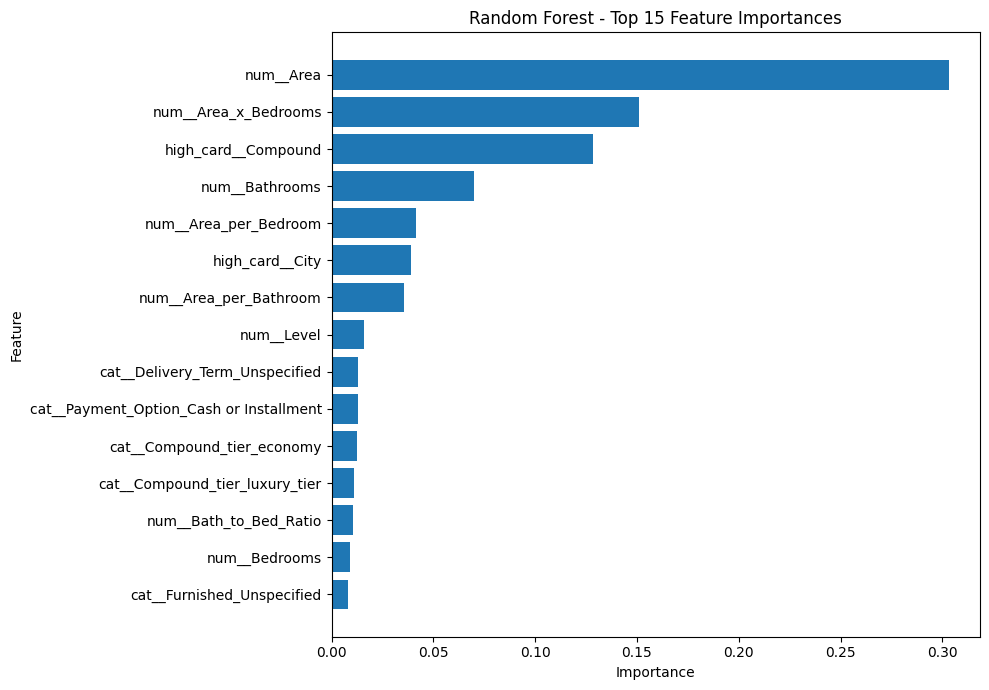

In [331]:
# TOP 15 FEATURE IMPORTANCES

# Get the trained Random Forest
rf = rf_pipeline.named_steps['model']
# Get feature names after One-Hot Encoding
feature_names = ( rf_pipeline.named_steps['preprocessor'].get_feature_names_out())
# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_ })
# Sort by importance
importance_df = importance_df.sort_values( by='Importance',ascending=False)
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top_features['Feature'][::-1],
         top_features['Importance'][::-1])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest - Top 15 Feature Importances')

plt.tight_layout()
plt.show()

In [ ]:
# xgboost model
from xgboost import XGBRegressor

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.1,        # L1 regularization
        reg_lambda=1.0,       # L2 regularization
        random_state=42,
        n_jobs=-1,
    ))  ])

xgb_pipeline.fit(X_train, y_train)

y_pred_log  = xgb_pipeline.predict(X_test)
y_pred      = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

mae     = mean_absolute_error(y_test_real, y_pred)
rmse    = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2      = r2_score(y_test_real, y_pred)
r2_log  = r2_score(y_test, y_pred_log)

print("XGBoost Results")
print("─" * 40)
print(f"MAE  : {mae:,.0f} EGP")
print(f"RMSE : {rmse:,.0f} EGP")
print(f"R²   : {r2:.4f}  (real scale)")
print(f"R²   : {r2_log:.4f}  (log scale)")

XGBoost Results
────────────────────────────────────────
MAE  : 1,721,121 EGP
RMSE : 3,899,379 EGP
R²   : 0.6653  (real scale)
R²   : 0.6903  (log scale)


In [ ]:
# Optuna hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 400, 1200),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':        trial.suggest_int('max_depth', 4, 9),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }

    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(**params, random_state=42, n_jobs=-1))
    ])
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return r2_score(y_test, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)  # ~5-10 min

print("Best R²:", study.best_value)
print("Best params:", study.best_params)

Best R²: 0.6972331268083145
Best params: {'n_estimators': 761, 'learning_rate': 0.02050499651449728, 'max_depth': 9, 'subsample': 0.9767419471789744, 'colsample_bytree': 0.554162746171605, 'reg_alpha': 0.4209099680577163, 'reg_lambda': 1.3951064973130363, 'min_child_weight': 9}


In [ ]:
#  Check how many unique compounds 
print(df_filtered['Compound'].value_counts().head(20))
print(f"Total compounds: {df_filtered['Compound'].nunique()}")

#  Check price variance WITHIN the same compound+type+area
# If this is high, the model can never do better with current features
sample = df_filtered.groupby(['Compound', 'Type', 'Bedrooms'])['Price'].agg(['mean','std','count'])
print(sample[sample['count'] >= 5].sort_values('std', ascending=False).head(20))

#  Check price distribution — are there still weird outliers?
import matplotlib.pyplot as plt
df_filtered['Price'].describe()

Compound
Outside Compound             10389
Madinaty                      1064
Mountain View North Coast      721
Hyde Park New Cairo            445
Rehab City                     405
Marassi                        362
Mountain View iCity            361
Amwaj                          334
Not in Compound                304
Mivida                         296
Taj City                       256
Cali Coast                     246
Sarai                          215
Bianchi                        203
Villette                       177
Mountain View Hyde Park        161
Hacienda Bay                   160
IL Monte Galala                142
Fouka Bay                      140
Gaia                           139
Name: count, dtype: int64
Total compounds: 558
                                                       mean           std  \
Compound            Type             Bedrooms                               
Outside Compound    Standalone Villa 10        2.025000e+07  2.427781e+07   
             

,Price
count,2.518100e+04
mean,4.853615e+06
std,6.628051e+06
min,1.000000e+05
25%,1.200000e+06
50%,2.800000e+06
75%,6.000000e+06
max,1.200000e+08


In [ ]:
# See where the model fails most
results = pd.DataFrame({
    'Actual':    np.expm1(y_test.values),
    'Predicted': np.expm1(xgb_pipeline.predict(X_test)),
    'Type':      X_test['Type'].values,
    'Region':    X_test['Region'].values,
})
results['Error_pct'] = abs(results['Actual'] - results['Predicted']) / results['Actual'] * 100

# Which property types are hardest to predict?
print(results.groupby('Type')['Error_pct'].mean().sort_values(ascending=False))

# Which regions are hardest?
print(results.groupby('Region')['Error_pct'].mean().sort_values(ascending=False))

Type
Chalet              84.571641
Town House          72.777195
Standalone Villa    60.282182
Duplex              57.403382
Studio              54.662572
Penthouse           53.785107
Apartment           48.713632
Twin House          47.313823
Unspecified         32.995110
Name: Error_pct, dtype: float64
Region
North Coast          89.859660
New Capital          78.641848
Ain Sukhna           75.696267
Other Regions        51.508627
New Cairo            51.200227
Giza & West Cairo    50.200556
Alexandria           35.889232
Name: Error_pct, dtype: float64


In [ ]:

#  Define segments 
def assign_segment(row):
    # High-error vacation markets → their own segment
    if row['Region'] in ['North Coast', 'Ain Sukhna']:
        return 'vacation'
    # High-error luxury types → their own segment
    if row['Type'] in ['Chalet', 'Town House', 'Standalone Villa',
                        'Duplex', 'Penthouse']:
        return 'luxury'
    # Studios → separate (very different price dynamics)
    if row['Type'] == 'Studio':
        return 'studio'
    # The rest: Apartments + Twin House in urban areas → most reliable
    return 'urban_apartment'

model_df = df_filtered.copy()
model_df['log_Price'] = np.log1p(model_df['Price'])
model_df['Segment'] = model_df.apply(assign_segment, axis=1)

print(model_df['Segment'].value_counts())
print("\nSegment price stats:")
print(model_df.groupby('Segment')['Price'].agg(['mean','std','count']))

Segment
urban_apartment    9561
luxury             8177
vacation           7311
studio              132
Name: count, dtype: int64

Segment price stats:
                         mean           std  count
Segment                                           
luxury           8.330812e+06  9.044136e+06   8177
studio           1.281379e+06  1.056824e+06    132
urban_apartment  2.926948e+06  2.965448e+06   9561
vacation         3.548642e+06  5.291864e+06   7311


In [ ]:
#  Feature engineering (same as before) 
model_df['Area_x_Bedrooms']   = model_df['Area'] * model_df['Bedrooms']
model_df['Area_per_Bedroom']  = model_df['Area'] / model_df['Bedrooms'].replace(0,1)
model_df['Area_per_Bathroom'] = model_df['Area'] / model_df['Bathrooms'].replace(0,1)
model_df['Is_Ground']         = (model_df['Level'] == 0).astype(int)
model_df['Is_High_Floor']     = (model_df['Level'] >= 7).astype(int)
model_df['Is_Furnished_int']  = (model_df['Furnished'] == 'Yes').astype(int)

numeric_features = [
    'Bedrooms', 'Bathrooms', 'Area', 'Level',
    'Bath_to_Bed_Ratio', 'Area_x_Bedrooms',
    'Area_per_Bedroom', 'Area_per_Bathroom',
    'Is_Ground', 'Is_High_Floor', 'Is_Furnished_int', ]
categorical_features = [
    'Type', 'Furnished', 'Payment_Option',
    'Delivery_Term', 'Is_Compound', 'Is_Ready', 'Region', ]
high_card_features = ['Compound', 'City']

In [ ]:
#  Train one model per segment
from xgboost import XGBRegressor

# Best params from your Optuna run
best_params = {
    'n_estimators':     913,
    'learning_rate':    0.0153,
    'max_depth':        9,
    'subsample':        0.821,
    'colsample_bytree': 0.711,
    'reg_alpha':        0.622,
    'reg_lambda':       3.592,
    'min_child_weight': 2,
    'random_state':     42,
    'n_jobs':           -1,
}

segment_models  = {}
segment_results = {}
segment_splits  = {}

for seg in model_df['Segment'].unique():
    seg_data = model_df[model_df['Segment'] == seg].copy()
    print(f"\n── Segment: {seg}  ({len(seg_data)} rows) ──")

    if len(seg_data) < 200:
        print(f"  Too few rows — skipping separate model, will use global")
        continue

    X = seg_data[numeric_features + categorical_features + high_card_features]
    y = seg_data['log_Price']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42
    )

    preprocessor = ColumnTransformer(transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features),
        ('high_card', TargetEncoder(smoothing=10), high_card_features),])

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(**best_params)) ])

    pipeline.fit(X_train, y_train)

    y_pred_log  = pipeline.predict(X_test)
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)

    r2_log  = r2_score(y_test, y_pred_log)
    r2_real = r2_score(y_test_real, y_pred_real)
    mae     = mean_absolute_error(y_test_real, y_pred_real)
    err_pct = (abs(y_test_real - y_pred_real) / y_test_real * 100).mean()

    print(f"  R² log:  {r2_log:.4f}")
    print(f"  R² real: {r2_real:.4f}")
    print(f"  MAE:     {mae:,.0f} EGP")
    print(f"  Avg err: {err_pct:.1f}%")

    segment_models[seg]  = pipeline
    segment_results[seg] = {
        'r2_log': r2_log, 'r2_real': r2_real,
        'mae': mae, 'avg_error_pct': err_pct}
    
    segment_splits[seg] = (X_test, y_test)


── Segment: luxury  (8177 rows) ──
  R² log:  0.6385
  R² real: 0.5454
  MAE:     2,851,135 EGP
  Avg err: 64.0%

── Segment: urban_apartment  (9561 rows) ──
  R² log:  0.7141
  R² real: 0.7688
  MAE:     782,336 EGP
  Avg err: 45.8%

── Segment: vacation  (7311 rows) ──
  R² log:  0.5043
  R² real: 0.4796
  MAE:     1,674,137 EGP
  Avg err: 78.6%

── Segment: studio  (132 rows) ──
  ⚠ Too few rows — skipping separate model, will use global


In [ ]:
#  Prediction function that routes to correct model 
def predict_price(input_df, segment_models, model_df):
    """
    input_df: single-row DataFrame with all required columns
    Returns predicted price + confidence interval
    """
    # Assign segment
    row = input_df.iloc[0]
    seg = assign_segment(row)

    # Fall back to best global model if segment model doesn't exist
    if seg not in segment_models:
        seg = 'urban_apartment'  # most reliable fallback

    model = segment_models[seg]
    log_pred = model.predict(input_df[numeric_features +
                                      categorical_features +
                                      high_card_features])[0]
    price = np.expm1(log_pred)

    # Confidence interval based on known segment error
    error_rates = {
        'urban_apartment': 0.25,
        'luxury':          0.45,
        'studio':          0.30,
        'vacation':        0.65,   # very uncertain
    }
    margin = error_rates.get(seg, 0.35)

    return {
        'segment':    seg,
        'predicted':  price,
        'low':        price * (1 - margin),
        'high':       price * (1 + margin),
        'confidence': 'Low' if margin > 0.5 else
                      'Medium' if margin > 0.3 else 'High'
    }

In [ ]:
# Summary table 
print("\n" + "═"*55)
print(f"{'Segment':<20} {'R²(log)':>8} {'R²(real)':>9} {'Avg Err%':>9}")
print("═"*55)
for seg, res in segment_results.items():
    print(f"{seg:<20} {res['r2_log']:>8.4f} {res['r2_real']:>9.4f} "
          f"{res['avg_error_pct']:>8.1f}%")
print("═"*55)


═══════════════════════════════════════════════════════
Segment               R²(log)  R²(real)  Avg Err%
═══════════════════════════════════════════════════════
luxury                 0.6385    0.5454     64.0%
urban_apartment        0.7141    0.7688     45.8%
vacation               0.5043    0.4796     78.6%
═══════════════════════════════════════════════════════


In [323]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Use only urban_apartment data
seg_data = model_df[model_df['Segment'] == 'urban_apartment'].copy()
X = seg_data[numeric_features + categorical_features + high_card_features]
y = seg_data['log_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     categorical_features),
    ('high_card', TargetEncoder(smoothing=10), high_card_features),
])

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 500, 1500),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth':        trial.suggest_int('max_depth', 5, 10),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 3.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma':            trial.suggest_float('gamma', 0.0, 2.0),  # new
        'random_state':     42,
        'n_jobs':           -1,
    }

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(**params))
    ])
    pipeline.fit(X_train, y_train)
    return r2_score(y_test, pipeline.predict(X_test))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=80)

print(f"Best R² (log): {study.best_value:.4f}")
print("Best params:", study.best_params)

Best R² (log): 0.7153
Best params: {'n_estimators': 682, 'learning_rate': 0.016697306545448605, 'max_depth': 8, 'subsample': 0.7970567188102372, 'colsample_bytree': 0.6729343380862939, 'reg_alpha': 0.4594242516786801, 'reg_lambda': 1.102400957609619, 'min_child_weight': 5, 'gamma': 0.15689739029240532}


In [324]:
from lightgbm import LGBMRegressor

seg_data = model_df[model_df['Segment'] == 'urban_apartment'].copy()
X = seg_data[numeric_features + categorical_features + high_card_features]
y = seg_data['log_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     categorical_features),
    ('high_card', TargetEncoder(smoothing=10), high_card_features),
])

lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=8,
        num_leaves=100,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=2.0,
        min_child_samples=15,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ))
])

lgbm_pipeline.fit(X_train, y_train)

y_pred_log  = lgbm_pipeline.predict(X_test)
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

print(f"LightGBM urban_apartment R² log:  {r2_score(y_test, y_pred_log):.4f}")
print(f"LightGBM urban_apartment R² real: {r2_score(y_test_real, y_pred_real):.4f}")
print(f"MAE: {mean_absolute_error(y_test_real, y_pred_real):,.0f} EGP")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM urban_apartment R² log:  0.7109
LightGBM urban_apartment R² real: 0.7594
MAE: 804,383 EGP


In [334]:
import joblib
# Vacation properties are unpredictable — just show market stats

# Custom agg since quantile needs a lambda
vacation_stats = model_df[model_df['Segment'] == 'vacation'].groupby(
    ['Type', 'Region']
)['Price'].agg(
    median   = 'median',
    q25      = lambda x: x.quantile(0.25),
    q75      = lambda x: x.quantile(0.75),
    count    = 'count'
).reset_index()

print(vacation_stats)
joblib.dump(vacation_stats, 'vacation_stats.pkl')

                Type       Region     median        q25         q75  count
0          Apartment   Ain Sukhna  1604000.0  1227000.0   1799500.0      3
1          Apartment  North Coast  2450000.0   780000.0   3263975.0     24
2             Chalet   Ain Sukhna  1400000.0   590000.0   2321250.0   1304
3             Chalet  North Coast  2295000.0   500000.0   3532000.0   3932
4             Duplex   Ain Sukhna  1190000.0   581000.0   2500000.0     18
5             Duplex  North Coast  3779000.0   725050.0   4943250.0    126
6          Penthouse   Ain Sukhna  3300000.0  2193000.0   3700000.0     37
7          Penthouse  North Coast  3070400.0  1968419.0   4500000.0    169
8   Standalone Villa   Ain Sukhna  5300000.0  2135000.0   8005064.0     80
9   Standalone Villa  North Coast  9500000.0  3500000.0  18000000.0    533
10            Studio   Ain Sukhna  1035000.0   417500.0   1680000.0     19
11            Studio  North Coast   880000.0   800000.0   1587000.0     69
12        Town House   Ai

['vacation_stats.pkl']

In [335]:
import joblib

# Save the trained segment models
joblib.dump(segment_models, 'segment_models.pkl')
joblib.dump(model_df[['Compound','log_Price']].drop_duplicates(), 'compound_means.pkl')
joblib.dump(vacation_stats, 'vacation_stats.pkl')

print("Models saved successfully!")

Models saved successfully!
